# 🏠 Nairobi House Price Prediction
## End-to-End Pipeline: Raw Data → XGBoost (Optuna-Tuned) → model.pkl

---

| Phase | Description |
|---|---|
| **1. Setup** | Imports, configuration, colour palette |
| **2. Load Raw Data** | Load `raw_listings.csv` only |
| **3. Missing Values** | Diagnosis, structural cleaning, domain + statistical + MICE imputation |
| **4. Duplicates & Outliers** | Remove duplicate rows and extreme outliers |
| **5. Feature Engineering** | Price/sqft, amenity score, distance to CBD, derived features |
| **6. EDA** | Univariate, bivariate, and correlation analysis |
| **7. Encoding & Split** | Label-encode categoricals, train/test split |
| **8. Baseline Models** | Heuristic and Linear Regression benchmarks |
| **9. XGBoost + Optuna** | Hyperparameter search with Optuna, final training |
| **10. Evaluation** | MAE, RMSE, R², residual analysis, feature importance |
| **11. Save model.pkl** | Serialise model, encoders, and feature list |


---
## ⚙️ 1 — Setup: Imports & Configuration

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Install dependencies if not present
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['xgboost', 'optuna', 'joblib']:
    try:
        __import__(pkg)
    except ImportError:
        print(f'Installing {pkg}...')
        install(pkg)

print('✅ All dependencies ready.')

✅ All dependencies ready.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Core libraries
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
import os
import joblib
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.experimental import enable_iterative_imputer   # noqa
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# XGBoost + Optuna
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress verbose Optuna logs

# Math
from math import radians, cos, sin, asin, sqrt

# ─────────────────────────────────────────────────────────────────────────────
# Styling
# ─────────────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.figsize'   : (13, 5),
    'figure.dpi'       : 110,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# Colour palette
C = dict(
    drop   = '#e74c3c',
    warn   = '#f39c12',
    ok     = '#27ae60',
    blue   = '#2980b9',
    purple = '#8e44ad',
    before = '#e74c3c',
    after  = '#27ae60',
)

RANDOM_STATE = 42
print('✅ All imports successful.')

✅ All imports successful.


---
## 📂 2 — Load Raw Data

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Load ONLY the raw CSV — all cleaning happens below.
# ─────────────────────────────────────────────────────────────────────────────
RAW_PATH = './data/raw_listings.csv'   # ← update if your file lives elsewhere

df_raw = pd.read_csv(RAW_PATH)

# Work on a copy so df_raw is always available for comparison
df = df_raw.copy()

# Convert 'N/A' strings to proper NaN
df.replace('N/A', np.nan, inplace=True)

print(f'Raw dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Missing cells: {df.isnull().sum().sum():,}  ({df.isnull().mean().mean()*100:.1f}% overall)')
df.head(5)

Raw dataset: 926 rows × 8 columns
Missing cells: 2,427  (32.8% overall)


,Location,Property Type,Bedrooms,Bathrooms,Size (m2),Amenities,Price (KES),Listing Date
0,Westlands,Land,1.0,2.0,65.0,Swimming Pool,5500000.0,NaN
1,Westlands,Villa,6.0,6.0,NaN,En Suite,260000000.0,NaN
2,Kileleshwa,Apartment,1.0,2.0,65.0,Swimming Pool,6000000.0,NaN
3,Kileleshwa,Apartment,1.0,1.0,47.0,Swimming Pool,5100000.0,NaN
4,Westlands,Land,NaN,NaN,NaN,NaN,25000000.0,NaN


In [4]:
# Schema overview
df.info()
print('\n── Numeric summary ──')
display(df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 926 entries, 0 to 925
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       926 non-null    object 
 1   Property Type  926 non-null    object 
 2   Bedrooms       792 non-null    float64
 3   Bathrooms      463 non-null    float64
 4   Size (m2)      466 non-null    float64
 5   Amenities      696 non-null    object 
 6   Price (KES)    698 non-null    float64
 7   Listing Date   14 non-null     float64
dtypes: float64(5), object(3)
memory usage: 58.0+ KB

── Numeric summary ──


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Location,926,58,Westlands,159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Property Type,926,10,Apartment,376,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bedrooms,792.0,NaN,NaN,NaN,3.042929,2.853467,1.0,2.0,3.0,4.0,54.0
Bathrooms,463.0,NaN,NaN,NaN,3.062635,2.760726,1.0,2.0,3.0,4.0,44.0
Size (m2),466.0,NaN,NaN,NaN,1385.979828,5179.298461,8.0,70.0,166.5,500.0,80937.0
Amenities,696,191,SQ,210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (KES),698.0,NaN,NaN,NaN,56210929.861032,182676302.28412,65.0,9000000.0,15000000.0,43750000.0,2026000000.0
Listing Date,14.0,NaN,NaN,NaN,10.642857,3.177012,8.0,8.25,10.0,11.0,19.0


---
## 🔬 3 — Missing Value Handling
### 3.1 — Diagnosis

In [5]:
def missing_audit(dataframe):
    """Return a DataFrame summarising missingness per column."""
    total  = len(dataframe)
    counts = dataframe.isnull().sum()
    pct    = (counts / total * 100).round(2)

    def severity(p):
        if p == 0:    return '✅  None'
        if p < 5:     return '🟢 Low  (<5%)'
        if p < 20:    return '🟡 Moderate (5–20%)'
        if p < 55:    return '🟠 High (20–55%)'
        return            '🔴 Critical (>55%) — consider dropping'

    audit = pd.DataFrame({
        'Non-Missing'  : total - counts,
        'Missing Count': counts,
        'Missing %'    : pct,
        'Dtype'        : dataframe.dtypes.astype(str),
        'Severity'     : pct.map(severity)
    }).sort_values('Missing %', ascending=False)
    return audit

audit = missing_audit(df)
print('=== Missing Value Audit ===')
display(audit)

=== Missing Value Audit ===


,Non-Missing,Missing Count,Missing %,Dtype,Severity
Listing Date,14,912,98.49,float64,🔴 Critical (>55%) — consider dropping
Bathrooms,463,463,50.00,float64,🟠 High (20–55%)
Size (m2),466,460,49.68,float64,🟠 High (20–55%)
Amenities,696,230,24.84,object,🟠 High (20–55%)
Price (KES),698,228,24.62,float64,🟠 High (20–55%)
Bedrooms,792,134,14.47,float64,🟡 Moderate (5–20%)
Location,926,0,0.00,object,✅ None
Property Type,926,0,0.00,object,✅ None


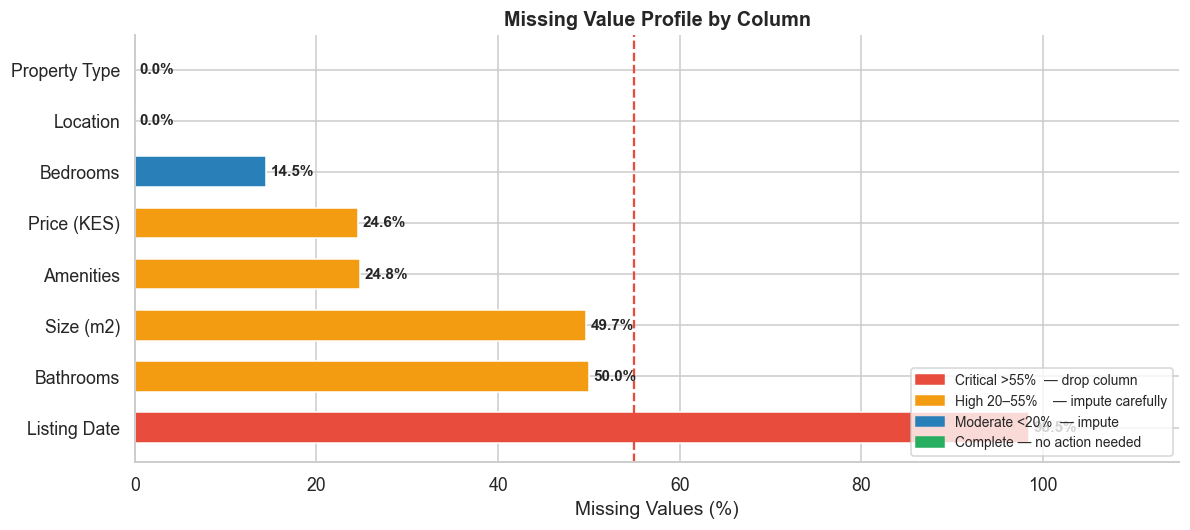

In [6]:
# ── Missing value bar chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = [
    C['drop'] if v > 55 else C['warn'] if v > 20 else C['blue'] if v > 0 else C['ok']
    for v in audit['Missing %']
]
bars = ax.barh(audit.index, audit['Missing %'], color=bar_colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, audit['Missing %']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.axvline(55, color=C['drop'], linestyle='--', linewidth=1.5, label='55% drop threshold')
legend_patches = [
    mpatches.Patch(color=C['drop'],  label='Critical >55%  — drop column'),
    mpatches.Patch(color=C['warn'],  label='High 20–55%    — impute carefully'),
    mpatches.Patch(color=C['blue'],  label='Moderate <20%  — impute'),
    mpatches.Patch(color=C['ok'],    label='Complete — no action needed'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Value Profile by Column', fontsize=13, fontweight='bold')
ax.set_xlim(0, 115)
plt.tight_layout()
plt.show()

### 3.2 — Structural Cleaning: Drop Columns > 55% Missing & Rows > 1 Missing

In [7]:
# ── Step A: Drop columns exceeding 55% missingness ─────────────────────────
COL_MISS_THRESHOLD = 55.0
miss_pct_cols = (df.isnull().sum() / len(df) * 100)
cols_to_drop  = miss_pct_cols[miss_pct_cols > COL_MISS_THRESHOLD].index.tolist()

print(f'Columns exceeding {COL_MISS_THRESHOLD}% threshold ({len(cols_to_drop)} dropped):')
for col in cols_to_drop:
    print(f'  • {col:20s}  →  {miss_pct_cols[col]:.1f}% missing')

df.drop(columns=cols_to_drop, inplace=True)
print(f'\n✅ Shape after column drop: {df.shape}')

Columns exceeding 55.0% threshold (1 dropped):
  • Listing Date          →  98.5% missing

✅ Shape after column drop: (926, 7)


In [8]:
# ── Step B: Drop rows with > 1 missing value ───────────────────────────────
ROW_MISS_THRESHOLD = 1
row_miss_count = df.isnull().sum(axis=1)
rows_before    = len(df)
df = df[row_miss_count <= ROW_MISS_THRESHOLD].reset_index(drop=True)

print(f'Rows dropped  : {rows_before - len(df):,}  ({(rows_before - len(df)) / rows_before * 100:.1f}%)')
print(f'Rows remaining: {len(df):,}')
print(f'Missing cells : {df.isnull().sum().sum()}')

Rows dropped  : 411  (44.4%)
Rows remaining: 515
Missing cells : 417


### 3.3 — Domain-Knowledge Imputation

In [9]:
# Studio / Bedsitter → Bedrooms = 1 by definition
ptype_norm   = df['Property Type'].str.strip().str.lower()
domain_mask  = df['Bedrooms'].isnull() & ptype_norm.isin(['studio', 'bedsitter'])
print(f'Domain-rule rows (Studio/Bedsitter with missing Bedrooms): {domain_mask.sum()}')
df.loc[domain_mask, 'Bedrooms'] = 1

# Amenities: fill remaining NaN with 'None'
if 'Amenities' in df.columns:
    df['Amenities'].fillna('None', inplace=True)

print('✅ Domain imputation applied.')

Domain-rule rows (Studio/Bedsitter with missing Bedrooms): 5
✅ Domain imputation applied.


### 3.4 — Statistical Imputation (Group-wise Median / Mode)

In [10]:
def group_median_fill(dataframe, fill_col, group_col='Property Type'):
    """Fill NaN with property-type group median, falling back to global median."""
    global_median = dataframe[fill_col].median()
    group_medians = dataframe.groupby(group_col)[fill_col].transform('median')
    return dataframe[fill_col].fillna(group_medians).fillna(global_median)

# Coerce numeric columns
for col in ['Bedrooms', 'Bathrooms', 'Size (m2)', 'Price (KES)']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where Price is still missing (cannot impute the target)
df.dropna(subset=['Price (KES)'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Fill Bedrooms with group-wise median (rounded to int)
before = df['Bedrooms'].isnull().sum()
df['Bedrooms'] = group_median_fill(df, 'Bedrooms').round().astype(int)
print(f'Bedrooms  : {before} NaN → 0  (group-median + round)')

print(f'\nMissing values remaining: {df.isnull().sum().sum()}')
display(df.isnull().sum()[df.isnull().sum() > 0].to_frame('Missing Count'))

Bedrooms  : 0 NaN → 0  (group-median + round)

Missing values remaining: 357


,Missing Count
Bathrooms,254
Size (m2),103


### 3.5 — Model-Based Imputation (MICE + Random Forest)

In [11]:
still_missing = df.isnull().sum()
model_target_cols = still_missing[still_missing > 0].index.tolist()
print(f'Columns still requiring imputation: {model_target_cols}')

if model_target_cols:
    # Encode categoricals for the imputer
    df_model  = df.copy()
    encoders_ = {}
    for col in df_model.select_dtypes(include='object').columns:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        encoders_[col] = le

    mice_imputer = IterativeImputer(
        estimator    = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1),
        max_iter     = 10,
        tol          = 1e-3,
        random_state = RANDOM_STATE,
        verbose      = 0,
    )

    print('Running MICE imputation — this may take a minute…')
    imputed_array = mice_imputer.fit_transform(df_model)
    df_imputed    = pd.DataFrame(imputed_array, columns=df_model.columns, index=df_model.index)

    # Restore integer columns
    for col in ['Bedrooms', 'Bathrooms']:
        if col in df_imputed.columns:
            df_imputed[col] = df_imputed[col].round().clip(lower=1).astype(int)

    # Clip Size and Price to sensible ranges
    for col, lo_q, hi_q in [('Size (m2)', 0.01, 0.99), ('Price (KES)', 0.01, 0.99)]:
        if col in df_imputed.columns:
            lo, hi = df[col].quantile([lo_q, hi_q])
            df_imputed[col] = df_imputed[col].clip(lower=lo, upper=hi)

    # Decode categoricals
    for col, le in encoders_.items():
        idx = df_imputed[col].round().astype(int).clip(0, len(le.classes_) - 1)
        df_imputed[col] = le.inverse_transform(idx)

    df = df_imputed.copy()
    print(f'✅ MICE imputation complete. NaN remaining: {df.isnull().sum().sum()}')
else:
    print('✅ No model-based imputation needed.')

assert df.isnull().sum().sum() == 0, '❌ Still have missing values!'
print(f'Dataset shape after imputation: {df.shape}')

Columns still requiring imputation: ['Bathrooms', 'Size (m2)']
Running MICE imputation — this may take a minute…
✅ MICE imputation complete. NaN remaining: 0
Dataset shape after imputation: (461, 7)


---
## 🗑️ 4 — Duplicate Removal & Outlier Filtering

In [12]:
# ── Duplicates ─────────────────────────────────────────────────────────────
dups = df.duplicated().sum()
print(f'Duplicate rows found: {dups}')
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Rows after dedup: {len(df):,}')

Duplicate rows found: 9
Rows after dedup: 452


In [13]:
# ── Outlier removal (IQR method, 1.5× IQR, 15th–85th pct bounds) ──────────
def remove_outliers_iqr(dataframe, column, q_lo=0.15, q_hi=0.85, multiplier=1.5):
    Q1, Q3 = dataframe[column].quantile(q_lo), dataframe[column].quantile(q_hi)
    IQR    = Q3 - Q1
    lo, hi = Q1 - multiplier * IQR, Q3 + multiplier * IQR
    mask   = dataframe[column].between(lo, hi)
    print(f'  {column:20s}: [{lo:>12,.0f} — {hi:>15,.0f}]  removed {(~mask).sum()} outliers')
    return dataframe[mask]

rows_before = len(df)
print('Removing outliers:')
for col in ['Price (KES)', 'Size (m2)', 'Bedrooms', 'Bathrooms']:
    if col in df.columns:
        df = remove_outliers_iqr(df, col)

df.reset_index(drop=True, inplace=True)
print(f'\n✅ Removed {rows_before - len(df):,} outlier rows. Remaining: {len(df):,}')

Removing outliers:
  Price (KES)         : [-102,750,000 —     189,650,000]  removed 10 outliers
  Size (m2)           : [      -1,368 —           2,459]  removed 39 outliers
  Bedrooms            : [          -4 —               8]  removed 2 outliers
  Bathrooms           : [          -5 —              11]  removed 1 outliers

✅ Removed 52 outlier rows. Remaining: 400


---
## 🔧 5 — Feature Engineering

In [14]:
# ── 5.1 Location standardisation ──────────────────────────────────────────
df['Location'] = df['Location'].str.strip().str.title()
location_mapping = {
    'Nrb': 'Nairobi', 'Nairobi Cbd': 'Nairobi', 'Cbd': 'Nairobi',
    'Thika Rd': 'Thika Road', 'Thika': 'Thika Road',
    'Lower Kabete': 'Kabete', 'Upper Kabete': 'Kabete',
}
df['Location'] = df['Location'].replace(location_mapping)
print(f'Unique locations after standardisation: {df["Location"].nunique()}')

Unique locations after standardisation: 43


In [15]:
# ── 5.2 Price per sqft ─────────────────────────────────────────────────────
df['price_per_sqft'] = (df['Price (KES)'] / df['Size (m2)']).round(2)
print(f'price_per_sqft  median: {df["price_per_sqft"].median():,.0f} KES/m²')

price_per_sqft  median: 100,000 KES/m²


In [16]:
# ── 5.3 Amenity score ──────────────────────────────────────────────────────
def calculate_amenity_score(amenity_str):
    if pd.isna(amenity_str) or str(amenity_str).strip().lower() in ('', 'none'):
        return 0.0
    s = amenity_str.lower()
    score = 0.0
    if 'swimming pool' in s or 'pool' in s:   score += 2.0
    if 'gym' in s or 'fitness' in s:           score += 2.0
    if 'generator' in s:                        score += 2.0
    if 'lift' in s or 'elevator' in s:          score += 1.5
    if 'cctv' in s or 'security' in s:          score += 1.0
    if 'borehole' in s or 'water' in s:         score += 1.0
    # Count remaining amenities (each 0.5 pts)
    extras = [a.strip() for a in amenity_str.split(',')]
    for am in extras:
        al = am.lower()
        if not any(k in al for k in ['pool', 'gym', 'fitness', 'generator', 'lift', 'elevator', 'cctv', 'security', 'borehole', 'water']):
            score += 0.5
    return round(score, 1)

if 'Amenities' in df.columns:
    df['amenity_score'] = df['Amenities'].apply(calculate_amenity_score)
    df['amenity_count'] = df['Amenities'].apply(
        lambda x: len(x.split(',')) if pd.notna(x) and str(x).strip().lower() != 'none' else 0
    )
else:
    df['amenity_score'] = 0
    df['amenity_count'] = 0

print(f'amenity_score  mean: {df["amenity_score"].mean():.2f}  max: {df["amenity_score"].max()}')

amenity_score  mean: 0.95  max: 8.5


In [17]:
# ── 5.4 Distance to Nairobi CBD (Haversine) ────────────────────────────────
CBD_LAT, CBD_LON = -1.2864, 36.8172

LOCATION_COORDS = {
    'Westlands': (-1.2636, 36.8031), 'Kilimani': (-1.2921, 36.7833),
    'Kileleshwa': (-1.2842, 36.7742), 'Lavington': (-1.2777, 36.7760),
    'Karen': (-1.3190, 36.7133), 'Runda': (-1.2110, 36.7986),
    'Muthaiga': (-1.2534, 36.8327), 'Parklands': (-1.2600, 36.8190),
    'Gigiri': (-1.2299, 36.8056), 'Spring Valley': (-1.2570, 36.7780),
    'Loresho': (-1.2560, 36.7638), 'Langata': (-1.3410, 36.7470),
    'South C': (-1.3100, 36.8220), 'South B': (-1.3040, 36.8370),
    'Embakasi': (-1.3190, 36.8960), 'Ruaka': (-1.2073, 36.7506),
    'Thika Road': (-1.2167, 36.8700), 'Syokimau': (-1.3640, 36.9150),
    'Athi River': (-1.4580, 36.9793), 'Kikuyu': (-1.2490, 36.6660),
    'Ruiru': (-1.1460, 36.9590), 'Mombasa Road': (-1.3380, 36.8680),
    'Ngong': (-1.3644, 36.6567), 'Limuru': (-1.1160, 36.6400),
    'Eastleigh': (-1.2724, 36.8539), 'Upperhill': (-1.2966, 36.8173),
    'Nairobi': (CBD_LAT, CBD_LON), 'Kabete': (-1.2490, 36.7270),
}

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi   = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

def get_distance(location):
    coords = LOCATION_COORDS.get(location, (CBD_LAT, CBD_LON))
    return haversine(coords[0], coords[1], CBD_LAT, CBD_LON)

df['distance_to_cbd_km'] = df['Location'].apply(get_distance)
print(f'distance_to_cbd_km  mean: {df["distance_to_cbd_km"].mean():.2f} km')

distance_to_cbd_km  mean: 3.46 km


In [18]:
# ── 5.5 Additional derived features ───────────────────────────────────────
df['total_rooms']            = df['Bedrooms'] + df['Bathrooms']
df['room_density']           = (df['total_rooms'] / df['Size (m2)']).round(4)
df['bathroom_bedroom_ratio'] = (df['Bathrooms'] / df['Bedrooms'].replace(0, 1)).round(2)

price_threshold = df['price_per_sqft'].quantile(0.90)
df['is_luxury'] = (
    (df['price_per_sqft'] >= price_threshold) & (df['amenity_score'] > 5)
).astype(int)

def simplify_property_type(ptype):
    p = ptype.lower()
    if any(k in p for k in ['apartment', 'studio', 'bedsitter']): return 'Apartment'
    if any(k in p for k in ['house', 'villa', 'bungalow', 'maisonette']): return 'House'
    if 'townhouse' in p: return 'Townhouse'
    return 'Other'

df['property_category'] = df['Property Type'].apply(simplify_property_type)

print('✅ Derived features created:')
for f in ['total_rooms', 'room_density', 'bathroom_bedroom_ratio', 'is_luxury', 'property_category']:
    print(f'   • {f}')
print(f'\nFinal dataset shape: {df.shape}')

✅ Derived features created:
   • total_rooms
   • room_density
   • bathroom_bedroom_ratio
   • is_luxury
   • property_category

Final dataset shape: (400, 16)


---
## 📊 6 — Exploratory Data Analysis

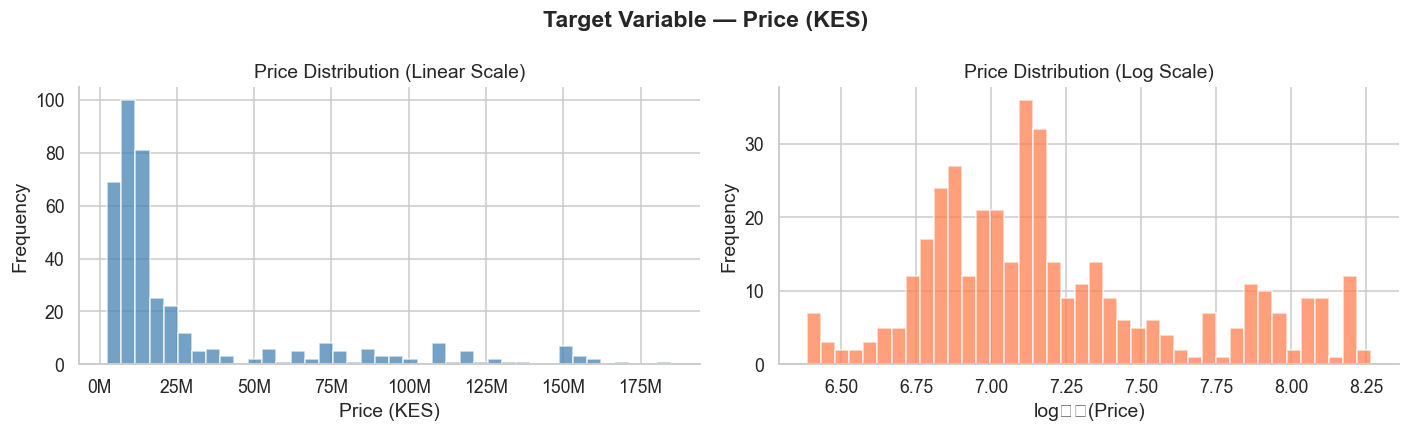

count            400
mean      29,716,344
std       38,251,111
min        2,432,000
25%        7,800,000
50%       13,200,000
75%       26,250,000
max      185,000,000
Name: Price (KES), dtype: object


In [19]:
# ── 6.1 Price distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['Price (KES)'], bins=40, color='steelblue', alpha=0.75, edgecolor='white')
axes[0].set_xlabel('Price (KES)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution (Linear Scale)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

axes[1].hist(np.log10(df['Price (KES)'].clip(lower=1)), bins=40, color='coral', alpha=0.75, edgecolor='white')
axes[1].set_xlabel('log₁₀(Price)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Price Distribution (Log Scale)')

plt.suptitle('Target Variable — Price (KES)', fontweight='bold')
plt.tight_layout()
plt.show()

print(df['Price (KES)'].describe().apply(lambda x: f'{x:,.0f}'))

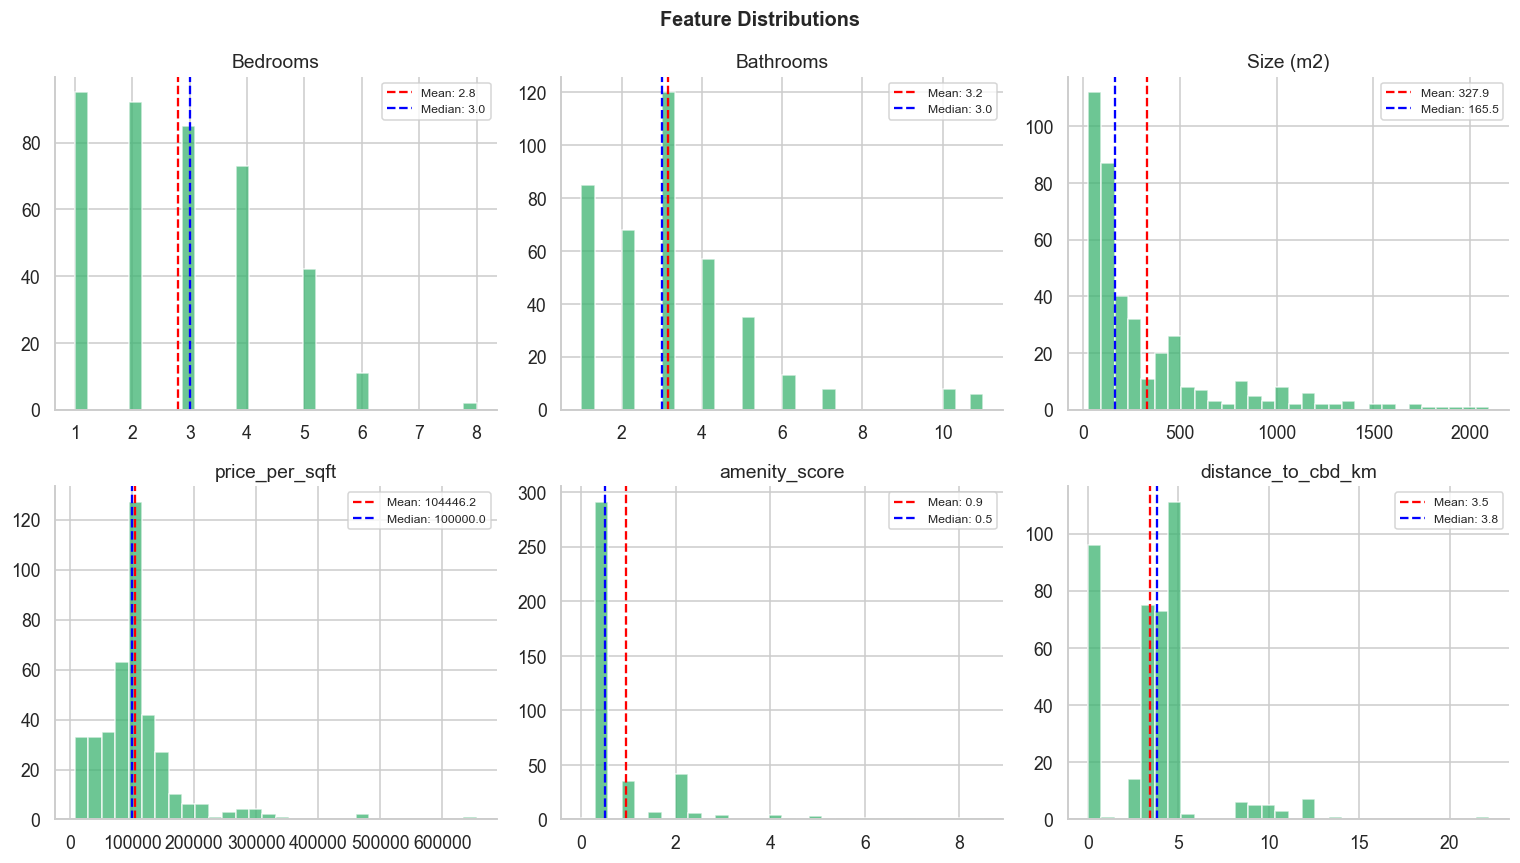

In [20]:
# ── 6.2 Key numeric feature distributions ─────────────────────────────────
num_features = ['Bedrooms', 'Bathrooms', 'Size (m2)', 'price_per_sqft', 'amenity_score', 'distance_to_cbd_km']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), num_features):
    ax.hist(df[col], bins=30, color='mediumseagreen', alpha=0.75, edgecolor='white')
    ax.axvline(df[col].mean(),   color='red',  linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='blue', linestyle='--', linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

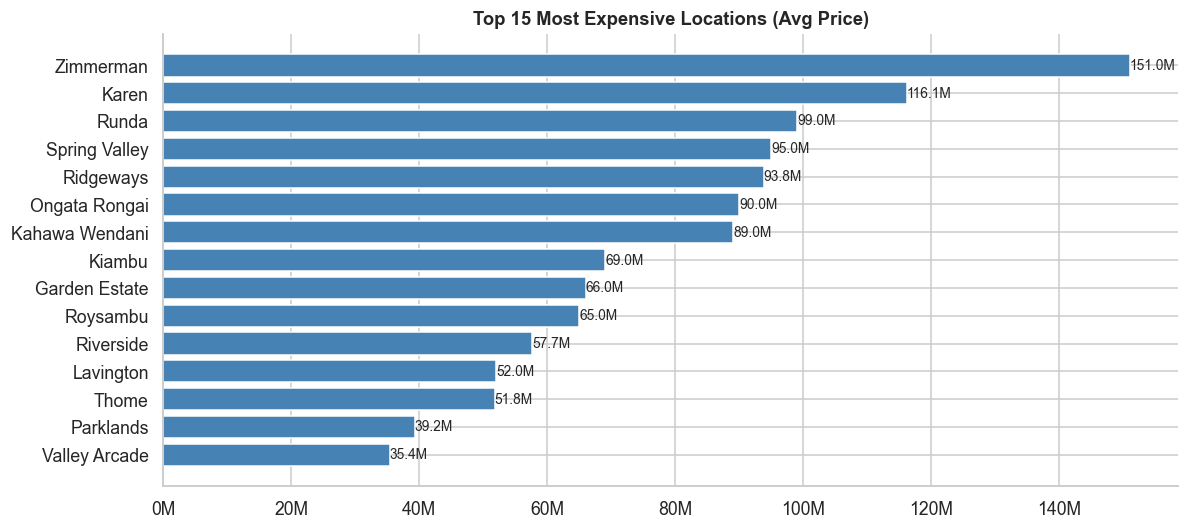

In [21]:
# ── 6.3 Top locations by average price ─────────────────────────────────────
loc_prices = df.groupby('Location')['Price (KES)'].mean().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(loc_prices.index[::-1], loc_prices.values[::-1], color='steelblue', edgecolor='white')
for bar, val in zip(bars, loc_prices.values[::-1]):
    ax.text(bar.get_width() + 2e4, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.1f}M', va='center', fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.set_title('Top 15 Most Expensive Locations (Avg Price)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

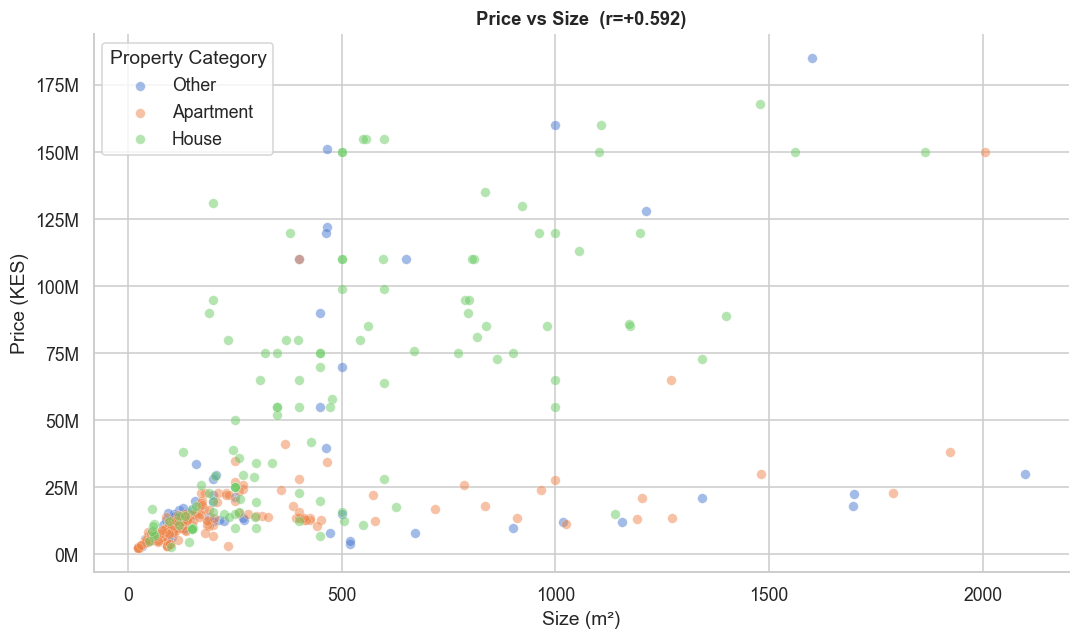

In [22]:
# ── 6.4 Price vs Size scatter ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for cat in df['property_category'].unique():
    sub = df[df['property_category'] == cat]
    ax.scatter(sub['Size (m2)'], sub['Price (KES)'], alpha=0.5, s=40, label=cat, edgecolors='white', linewidth=0.3)
ax.set_xlabel('Size (m²)')
ax.set_ylabel('Price (KES)')
ax.set_title(f'Price vs Size  (r={df["Size (m2)"].corr(df["Price (KES)"]):+.3f})', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.legend(title='Property Category')
plt.tight_layout()
plt.show()

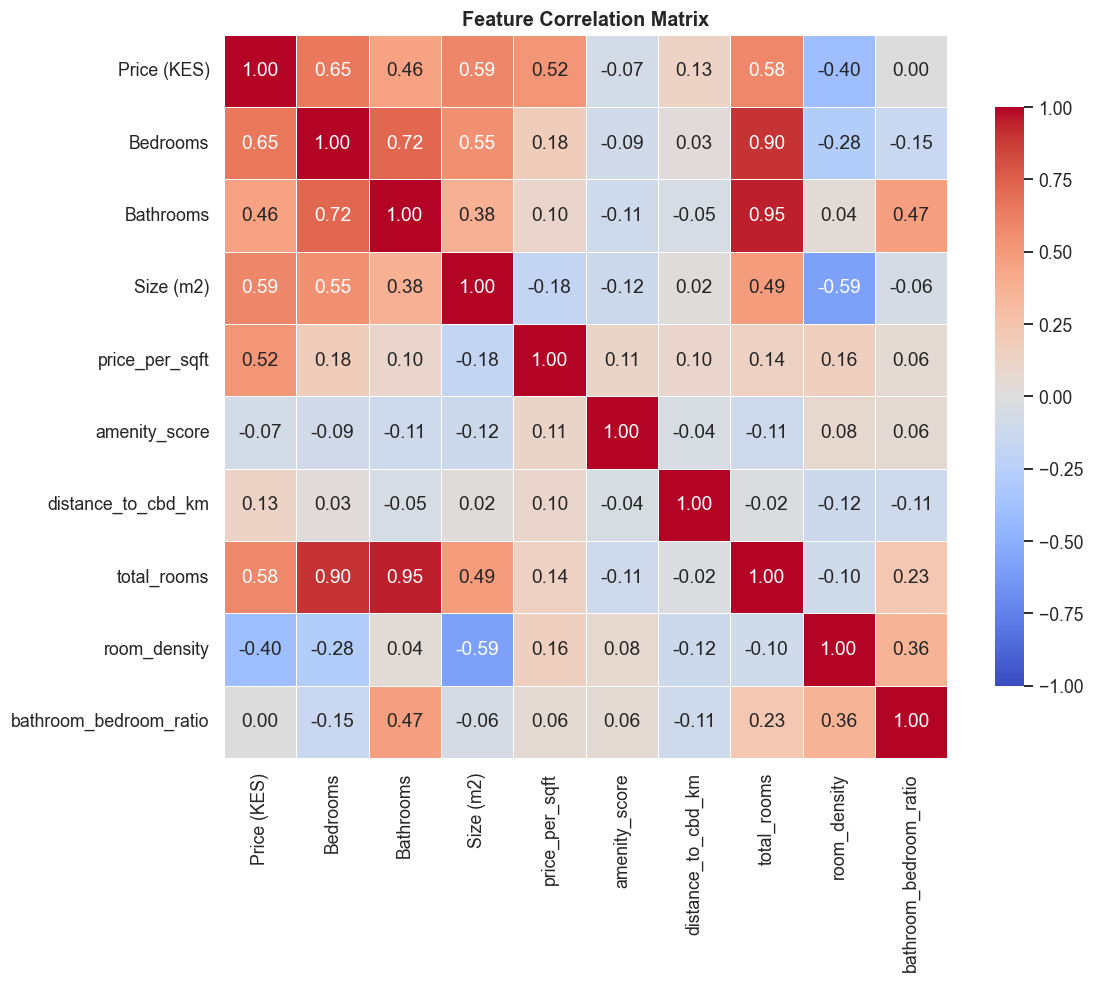

In [23]:
# ── 6.5 Correlation heatmap ────────────────────────────────────────────────
num_cols = ['Price (KES)', 'Bedrooms', 'Bathrooms', 'Size (m2)',
            'price_per_sqft', 'amenity_score', 'distance_to_cbd_km',
            'total_rooms', 'room_density', 'bathroom_bedroom_ratio']
corr = df[[c for c in num_cols if c in df.columns]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, vmin=-1, vmax=1, ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔢 7 — Encoding & Train/Test Split

In [24]:
TARGET = 'Price (KES)'

NUMERIC_FEATURES = [
    'Bedrooms', 'Bathrooms', 'Size (m2)',
    'distance_to_cbd_km', 'amenity_score', 'amenity_count',
    'price_per_sqft', 'total_rooms', 'room_density',
    'bathroom_bedroom_ratio', 'is_luxury',
]
CATEGORICAL_FEATURES = ['Property Type', 'Location']

# Filter to existing columns
NUMERIC_FEATURES      = [f for f in NUMERIC_FEATURES      if f in df.columns]
CATEGORICAL_FEATURES  = [f for f in CATEGORICAL_FEATURES  if f in df.columns]

df_model = df.copy()
label_encoders = {}

for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le
    print(f'  Encoded "{col}" → {len(le.classes_)} classes')

ALL_FEATURES = NUMERIC_FEATURES + [c + '_enc' for c in CATEGORICAL_FEATURES]
print(f'\n✅ Total features: {len(ALL_FEATURES)}')
print(ALL_FEATURES)

  Encoded "Property Type" → 10 classes
  Encoded "Location" → 43 classes

✅ Total features: 13
['Bedrooms', 'Bathrooms', 'Size (m2)', 'distance_to_cbd_km', 'amenity_score', 'amenity_count', 'price_per_sqft', 'total_rooms', 'room_density', 'bathroom_bedroom_ratio', 'is_luxury', 'Property Type_enc', 'Location_enc']


In [25]:
X = df_model[ALL_FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Training set : {X_train.shape[0]:,} rows')
print(f'Test set     : {X_test.shape[0]:,} rows')

Training set : 320 rows
Test set     : 80 rows


---
## 📏 8 — Baseline Models

In [26]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  MAE  : {mae:>15,.0f} KES')
    print(f'  RMSE : {rmse:>15,.0f} KES')
    print(f'  R²   : {r2:>15.4f}')
    return {'Model': name, 'MAE (KES)': mae, 'RMSE (KES)': rmse, 'R²': r2}

results = []

# ── Heuristic baseline ─────────────────────────────────────────────────────
print('── Heuristic (avg price/m²) ──')
avg_price_per_m2 = y_train.sum() / X_train['Size (m2)'].sum()
heuristic_pred   = X_test['Size (m2)'] * avg_price_per_m2
results.append(evaluate('Heuristic', y_test, heuristic_pred))

# ── Linear Regression ──────────────────────────────────────────────────────
print('\n── Linear Regression ──')
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results.append(evaluate('Linear Regression', y_test, lr_pred))

── Heuristic (avg price/m²) ──
  MAE  :      18,547,627 KES
  RMSE :      38,163,039 KES
  R²   :          0.0454

── Linear Regression ──
  MAE  :      11,545,014 KES
  RMSE :      17,243,188 KES
  R²   :          0.8051


---
## ⚡ 9 — XGBoost + Optuna Hyperparameter Tuning

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Optuna objective: each trial trains XGBoost with sampled hyperparameters
# and returns the validation RMSE (we minimise RMSE).
# ─────────────────────────────────────────────────────────────────────────────

def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 200, 1000, step=50),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel' : trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 20),
        'gamma'             : trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
        'random_state'      : RANDOM_STATE,
        'n_jobs'            : -1,
        'tree_method'       : 'hist',
        'verbosity'         : 0,
    }

    model = xgb.XGBRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False,
    )
    preds = model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, preds))   # minimise RMSE


# ─────────────────────────────────────────────────────────────────────────────
# Run Optuna study
# n_trials=50 gives a thorough search; reduce to 20 for a faster run.
# ─────────────────────────────────────────────────────────────────────────────
N_TRIALS = 50

study = optuna.create_study(
    direction  = 'minimize',
    study_name = 'xgb_nairobi_house_price',
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner     = optuna.pruners.MedianPruner(n_warmup_steps=10),
)

print(f'Running Optuna search ({N_TRIALS} trials)…')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\n✅ Optuna complete.')
print(f'   Best RMSE : {study.best_value:,.0f} KES')
print(f'   Best params:')
for k, v in study.best_params.items():
    print(f'     {k:25s}: {v}')

Running Optuna search (50 trials)…


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Optuna complete.
   Best RMSE : 9,005,706 KES
   Best params:
     n_estimators             : 550
     learning_rate            : 0.024923194647075805
     max_depth                : 3
     subsample                : 0.5127401179887896
     colsample_bytree         : 0.8790413776053737
     colsample_bylevel        : 0.8696172335104363
     min_child_weight         : 4
     gamma                    : 1.1967861083511557
     reg_alpha                : 0.0027799561367399766
     reg_lambda               : 0.12946789033684453


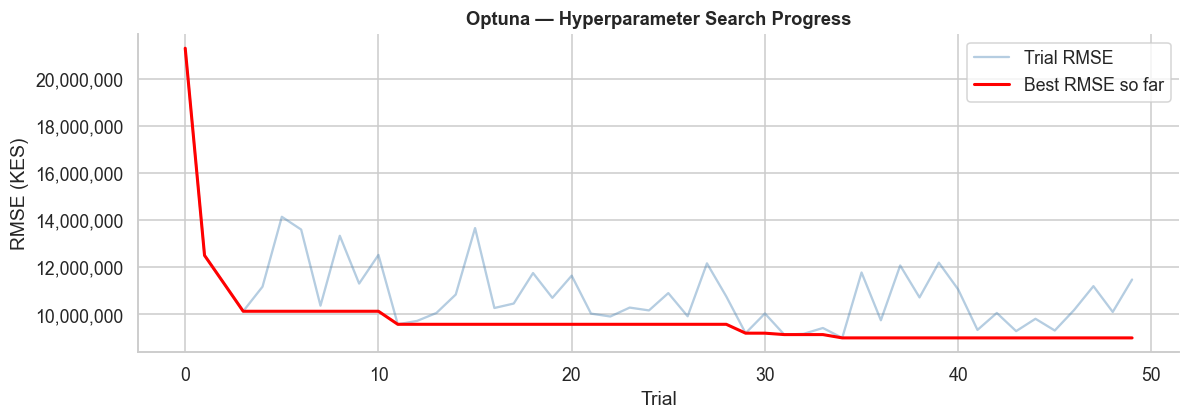

In [28]:
# ── Optuna optimisation history ────────────────────────────────────────────
trial_rmses = [t.value for t in study.trials if t.value is not None]
best_so_far = np.minimum.accumulate(trial_rmses)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(trial_rmses, alpha=0.4, color='steelblue', label='Trial RMSE')
ax.plot(best_so_far, color='red', linewidth=2, label='Best RMSE so far')
ax.set_xlabel('Trial')
ax.set_ylabel('RMSE (KES)')
ax.set_title('Optuna — Hyperparameter Search Progress', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
# ── Train final XGBoost model with best hyperparameters ────────────────────
best_params = dict(study.best_params)
best_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1, 'tree_method': 'hist', 'verbosity': 0})

print('Training final XGBoost model with best hyperparameters…')
xgb_model = xgb.XGBRegressor(**best_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

xgb_pred = xgb_model.predict(X_test)
print('\n── XGBoost (Optuna-tuned) ──')
results.append(evaluate('XGBoost (Optuna)', y_test, xgb_pred))

# Cross-validation R² for robustness estimate
cv_scores = cross_val_score(xgb_model, X, y, scoring='r2', cv=5)
print(f'  CV R²  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  (5-fold)')

Training final XGBoost model with best hyperparameters…

── XGBoost (Optuna-tuned) ──
  MAE  :       4,556,948 KES
  RMSE :       9,005,706 KES
  R²   :          0.9468
  CV R²  : 0.9477 ± 0.0189  (5-fold)


---
## 📋 10 — Model Comparison & Evaluation

In [32]:
# ── Comparison table ───────────────────────────────────────────────────────
comparison_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)

display_df = comparison_df.copy()
display_df['MAE (KES)']  = display_df['MAE (KES)'].apply(lambda x: f'{x:,.0f}')
display_df['RMSE (KES)'] = display_df['RMSE (KES)'].apply(lambda x: f'{x:,.0f}')
display_df['R²']         = display_df['R²'].apply(lambda x: f'{x:.4f}')

print('=' * 65)
print('MODEL COMPARISON TABLE')
print('=' * 65)
print(display_df.to_string(index=False))
print('=' * 65)

best_row  = comparison_df.iloc[0]
BEST_NAME = best_row['Model']
print(f'\n🏆 Best model: {BEST_NAME}  (R² = {best_row["R²"]:.4f})')

MODEL COMPARISON TABLE
            Model  MAE (KES) RMSE (KES)     R²
 XGBoost (Optuna)  4,556,948  9,005,706 0.9468
 XGBoost (Optuna)  4,556,948  9,005,706 0.9468
 XGBoost (Optuna)  4,556,948  9,005,706 0.9468
Linear Regression 11,545,014 17,243,188 0.8051
        Heuristic 18,547,627 38,163,039 0.0454

🏆 Best model: XGBoost (Optuna)  (R² = 0.9468)


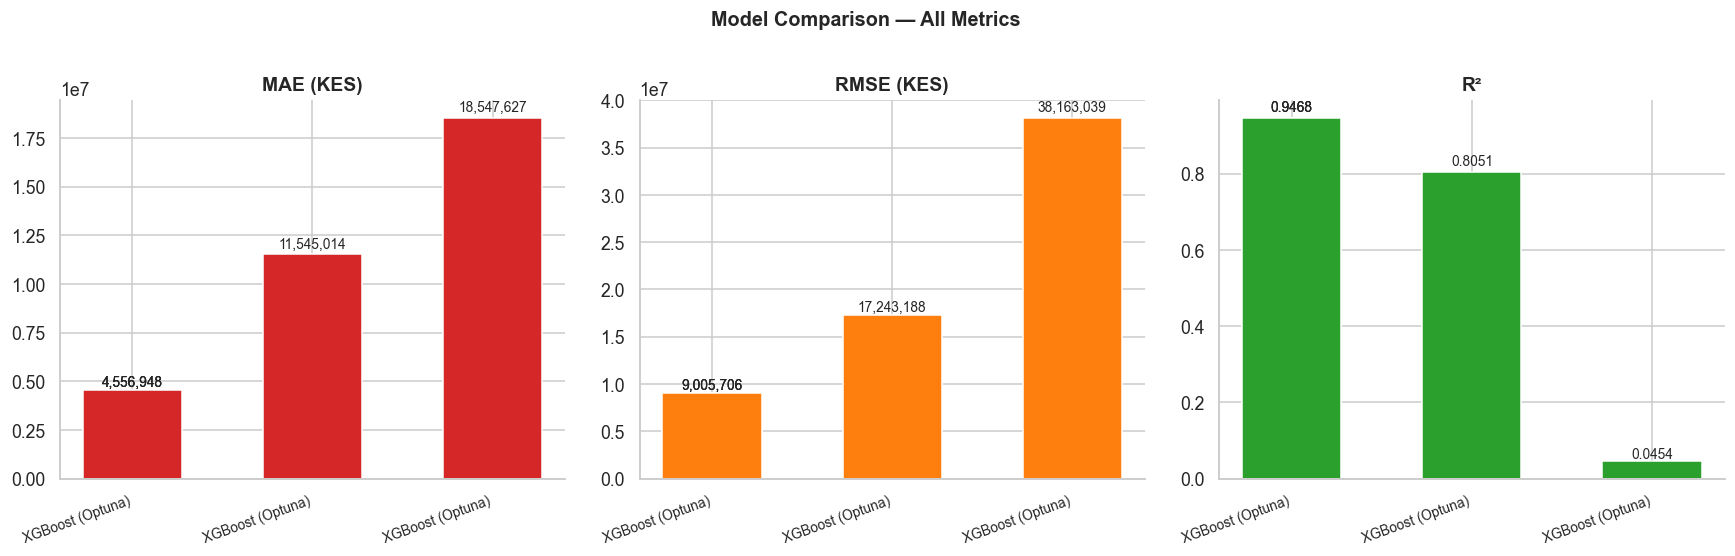

In [33]:
# ── Comparison bar charts ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#d62728', '#ff7f0e', '#2ca02c']
for ax, metric, color in zip(axes, ['MAE (KES)', 'RMSE (KES)', 'R²'], colors):
    bars = ax.bar(comparison_df['Model'], comparison_df[metric], color=color, edgecolor='white', width=0.55)
    ax.set_title(metric, fontweight='bold')
    ax.set_xticklabels(comparison_df['Model'], rotation=20, ha='right', fontsize=9)
    for bar in bars:
        h = bar.get_height()
        lbl = f'{h:,.0f}' if 'KES' in metric else f'{h:.4f}'
        ax.text(bar.get_x() + bar.get_width()/2., h * 1.01, lbl, ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison — All Metrics', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

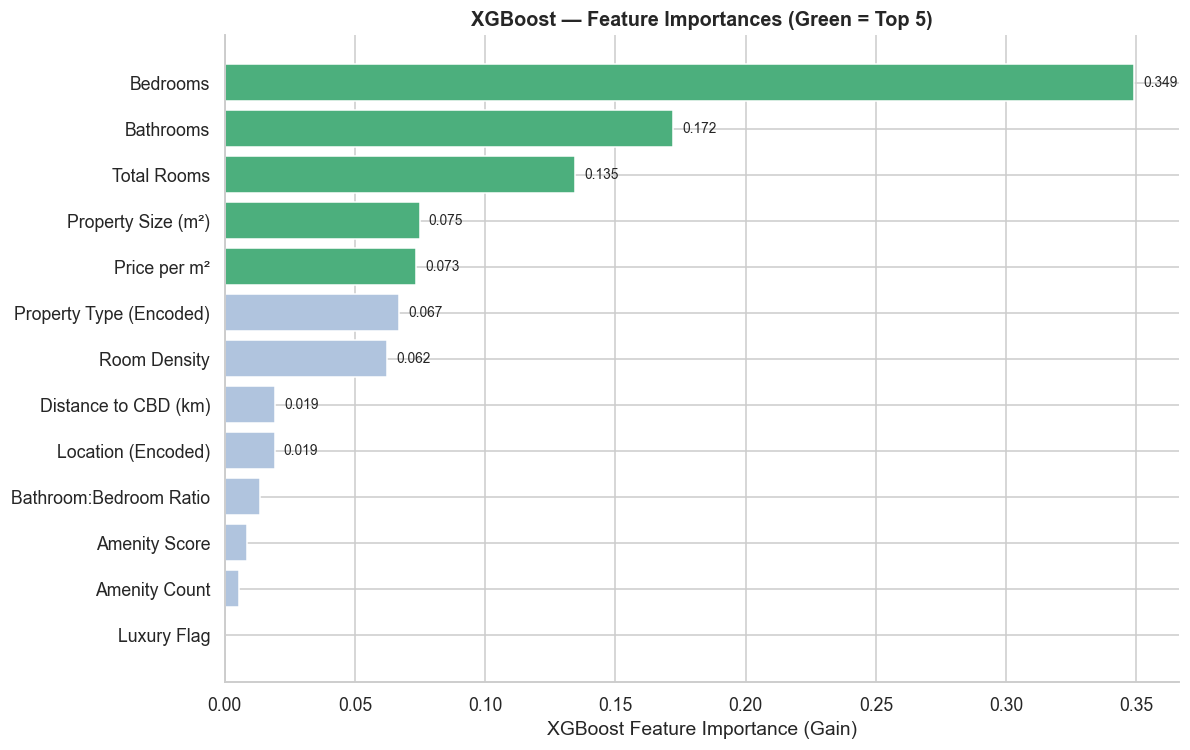


📌 TOP 5 PRICE DRIVERS:
  1. Price per m²                        importance = 0.0735  (7.3%)
  2. Property Size (m²)                  importance = 0.0748  (7.5%)
  3. Total Rooms                         importance = 0.1346  (13.5%)
  4. Bathrooms                           importance = 0.1721  (17.2%)
  5. Bedrooms                            importance = 0.3490  (34.9%)


In [34]:
# ── Feature importance — XGBoost ───────────────────────────────────────────
importances = pd.Series(xgb_model.feature_importances_, index=ALL_FEATURES).sort_values()

LABEL_MAP = {
    'Size (m2)': 'Property Size (m²)',
    'distance_to_cbd_km': 'Distance to CBD (km)',
    'amenity_score': 'Amenity Score',
    'price_per_sqft': 'Price per m²',
    'Bedrooms': 'Bedrooms',
    'Bathrooms': 'Bathrooms',
    'total_rooms': 'Total Rooms',
    'room_density': 'Room Density',
    'bathroom_bedroom_ratio': 'Bathroom:Bedroom Ratio',
    'is_luxury': 'Luxury Flag',
    'Location_enc': 'Location (Encoded)',
    'Property Type_enc': 'Property Type (Encoded)',
    'amenity_count': 'Amenity Count',
}
importances.index = [LABEL_MAP.get(f, f) for f in importances.index]

top5 = importances.nlargest(5)
colors_bar = ['#4CAF7D' if feat in top5.index else '#B0C4DE' for feat in importances.index]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(importances.index, importances.values, color=colors_bar, edgecolor='white')
ax.set_xlabel('XGBoost Feature Importance (Gain)')
ax.set_title('XGBoost — Feature Importances (Green = Top 5)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, importances.values):
    if val > importances.max() * 0.05:
        ax.text(bar.get_width() + importances.max()*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\n📌 TOP 5 PRICE DRIVERS:')
for i, (feat, score) in enumerate(top5[::-1].items(), 1):
    pct = score / importances.sum() * 100
    print(f'  {i}. {feat:<35} importance = {score:.4f}  ({pct:.1f}%)')

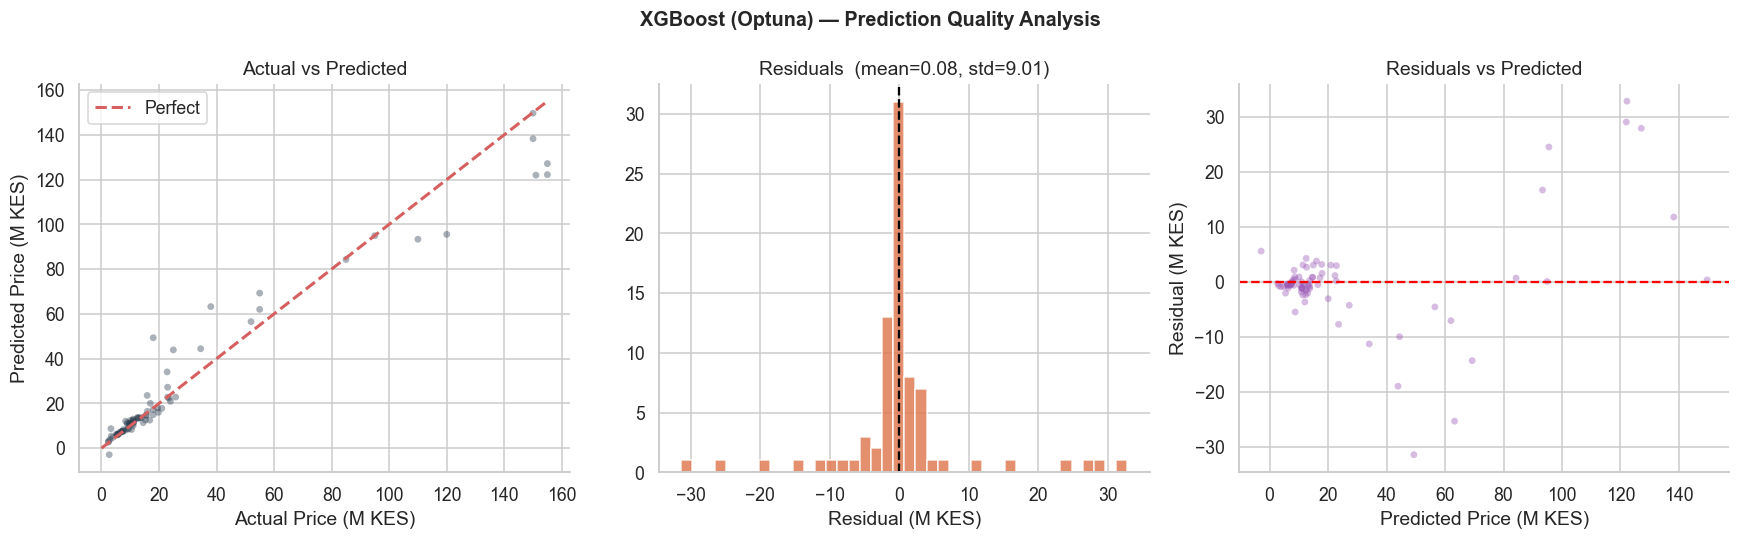

In [35]:
# ── Actual vs Predicted & Residuals ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1 — Actual vs Predicted
ax = axes[0]
max_val = max(y_test.max(), xgb_pred.max())
ax.scatter(y_test / 1e6, xgb_pred / 1e6, alpha=0.4, color='#2c3e50', edgecolors='none', s=20)
ax.plot([0, max_val/1e6], [0, max_val/1e6], 'r--', linewidth=2, label='Perfect')
ax.set_xlabel('Actual Price (M KES)')
ax.set_ylabel('Predicted Price (M KES)')
ax.set_title('Actual vs Predicted')
ax.legend()

# 2 — Residual distribution
ax  = axes[1]
res = (y_test.values - xgb_pred) / 1e6
ax.hist(res, bins=40, color='#E07B54', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Residual (M KES)')
ax.set_title(f'Residuals  (mean={res.mean():.2f}, std={res.std():.2f})')

# 3 — Residuals vs Predicted
ax = axes[2]
ax.scatter(xgb_pred / 1e6, res, alpha=0.4, color='#9B59B6', edgecolors='none', s=20)
ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('Predicted Price (M KES)')
ax.set_ylabel('Residual (M KES)')
ax.set_title('Residuals vs Predicted')

plt.suptitle('XGBoost (Optuna) — Prediction Quality Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 💾 11 — Save model.pkl

In [36]:
MODEL_PATH = 'model.pkl'

model_artefact = {
    'model'          : xgb_model,
    'features'       : ALL_FEATURES,
    'label_encoders' : label_encoders,
    'target'         : TARGET,
    'model_name'     : 'XGBoost (Optuna-tuned)',
    'best_params'    : best_params,
    'optuna_study'   : study,
    'test_r2'        : float(r2_score(y_test, xgb_pred)),
    'test_mae'       : float(mean_absolute_error(y_test, xgb_pred)),
    'test_rmse'      : float(np.sqrt(mean_squared_error(y_test, xgb_pred))),
}

joblib.dump(model_artefact, MODEL_PATH, compress=3)
print(f'✅ model.pkl saved → {MODEL_PATH}')
print(f'   Size on disk: {os.path.getsize(MODEL_PATH) / 1024:.1f} KB')

# ── Quick reload verification ──────────────────────────────────────────────
loaded = joblib.load(MODEL_PATH)
verify_preds = loaded['model'].predict(X_test[:5])
print(f'\n✅ Reload verification — first 5 test predictions:')
for actual, pred in zip(y_test.values[:5], verify_preds):
    print(f'   Actual: {actual:>15,.0f} KES   Predicted: {pred:>15,.0f} KES')

✅ model.pkl saved → model.pkl
   Size on disk: 104.9 KB

✅ Reload verification — first 5 test predictions:
   Actual:      55,000,000 KES   Predicted:      69,285,848 KES
   Actual:      25,800,000 KES   Predicted:      22,857,224 KES
   Actual:       5,200,000 KES   Predicted:       6,344,502 KES
   Actual:      15,900,000 KES   Predicted:      23,593,054 KES
   Actual:      18,000,000 KES   Predicted:      49,350,872 KES


---
## 📋 12 — Pipeline Summary

In [37]:
xgb_r2   = float(r2_score(y_test, xgb_pred))
xgb_mae  = float(mean_absolute_error(y_test, xgb_pred))
xgb_rmse = float(np.sqrt(mean_squared_error(y_test, xgb_pred)))

print('=' * 65)
print('  NAIROBI HOUSE PRICE PREDICTION — PIPELINE SUMMARY')
print('=' * 65)

print(f"""
📂 DATA
  Raw rows                : {df_raw.shape[0]:,}
  Final cleaned rows      : {len(df):,}
  Features used           : {len(ALL_FEATURES)}

🔧 CLEANING STEPS
  1. Dropped columns >55% missing
  2. Dropped rows with >1 missing value
  3. Domain imputation (Studio/Bedsitter → Bedrooms=1)
  4. Group-wise median imputation (Bedrooms)
  5. MICE + RandomForest for remaining NaN
  6. Duplicate removal
  7. IQR outlier filtering

🔢 FEATURES ENGINEERED
  price_per_sqft, amenity_score, amenity_count,
  distance_to_cbd_km, total_rooms, room_density,
  bathroom_bedroom_ratio, is_luxury, property_category

⚡ MODEL: XGBoost  (Optuna-tuned, {N_TRIALS} trials)
  Best RMSE (Optuna)      : {study.best_value:>12,.0f} KES
  Test MAE                : {xgb_mae:>12,.0f} KES
  Test RMSE               : {xgb_rmse:>12,.0f} KES
  Test R²                 : {xgb_r2:>12.4f}
  5-Fold CV R²            : {cv_scores.mean():>12.4f} ± {cv_scores.std():.4f}

📌 TOP 5 PRICE DRIVERS:
""")

for i, (feat, score) in enumerate(top5[::-1].items(), 1):
    print(f'  {i}. {feat:<35} {score:.4f}')

print(f"""
💾 OUTPUT
  model.pkl  — XGBoost model + encoders + metadata
""")
print('=' * 65)

  NAIROBI HOUSE PRICE PREDICTION — PIPELINE SUMMARY

📂 DATA
  Raw rows                : 926
  Final cleaned rows      : 400
  Features used           : 13

🔧 CLEANING STEPS
  1. Dropped columns >55% missing
  2. Dropped rows with >1 missing value
  3. Domain imputation (Studio/Bedsitter → Bedrooms=1)
  4. Group-wise median imputation (Bedrooms)
  5. MICE + RandomForest for remaining NaN
  6. Duplicate removal
  7. IQR outlier filtering

🔢 FEATURES ENGINEERED
  price_per_sqft, amenity_score, amenity_count,
  distance_to_cbd_km, total_rooms, room_density,
  bathroom_bedroom_ratio, is_luxury, property_category

⚡ MODEL: XGBoost  (Optuna-tuned, 50 trials)
  Best RMSE (Optuna)      :    9,005,706 KES
  Test MAE                :    4,556,948 KES
  Test RMSE               :    9,005,706 KES
  Test R²                 :       0.9468
  5-Fold CV R²            :       0.9477 ± 0.0189

📌 TOP 5 PRICE DRIVERS:

  1. Price per m²                        0.0735
  2. Property Size (m²)                  